In [1]:
import os
os.chdir(r'C:\Users\Lenovo\Desktop\Diabetes_Classifier\notebooks')
os.chdir("..")
print(os.getcwd())


C:\Users\Lenovo\Desktop\Diabetes_Classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans  
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import shuffle
from src.data_preprocessing import scale,encode
from src.data_feature_engineering import features
from src.helperFunc import saveFile


In [3]:
df=pd.read_csv("data/clean/clean2.csv")
y=df['diagnosis']
X=df.drop(['diagnosis'],axis=1)

Age_x_BMI         0.223095
age               0.187974
Cluster 4         0.162520
ldl               0.150999
cluster_labels    0.146562
BMI/LDL           0.132076
lipids            0.126701
chol/ldl          0.118112
hdl               0.099277
HDL_x_LDL         0.094012
bmi               0.093862
BMI/HDL+LDL       0.090418
tg                0.083848
Cluster 5         0.082716
chol              0.063225
Cluster 2         0.055180
cr                0.049850
Cluster 3         0.039154
bun               0.033494
Cluster 1         0.033050
Cluster 0         0.026942
bun_x_cr          0.013663
gender            0.006955
anomaly_score     0.001459
dtype: float64


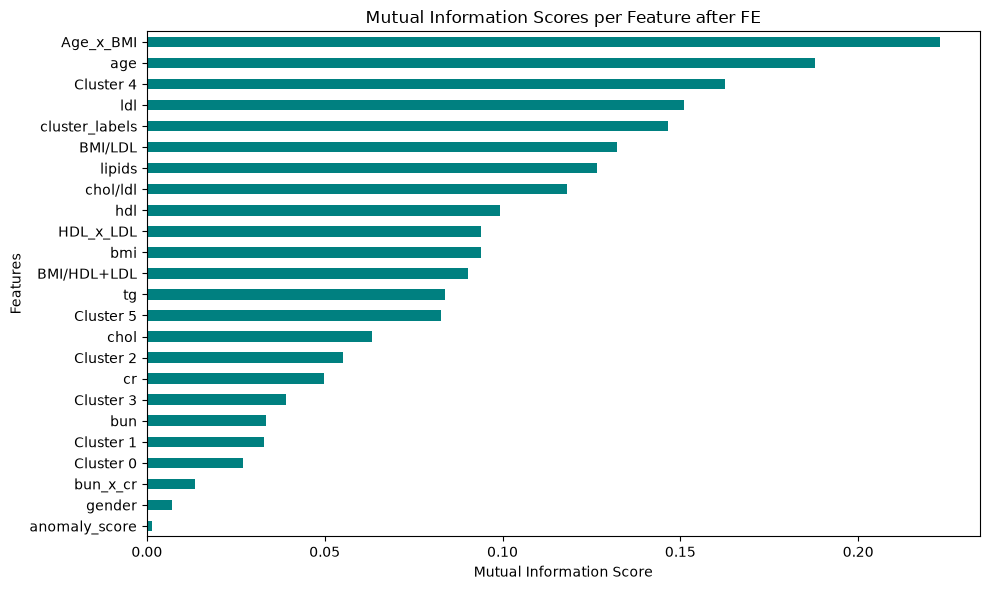

In [4]:
X=features(X)

feature= X.columns

mi_scores=mutual_info_classif(X,y,random_state=42,n_jobs=-1)

mi_scores_series = pd.Series(mi_scores, index=feature).sort_values(ascending=False)

print(mi_scores_series)     

plt.figure(figsize=(10, 6))
mi_scores_series.plot(kind='barh', color='teal')
plt.title('Mutual Information Scores per Feature after FE')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.gca().invert_yaxis() # Top-down display
plt.tight_layout()
plt.show()

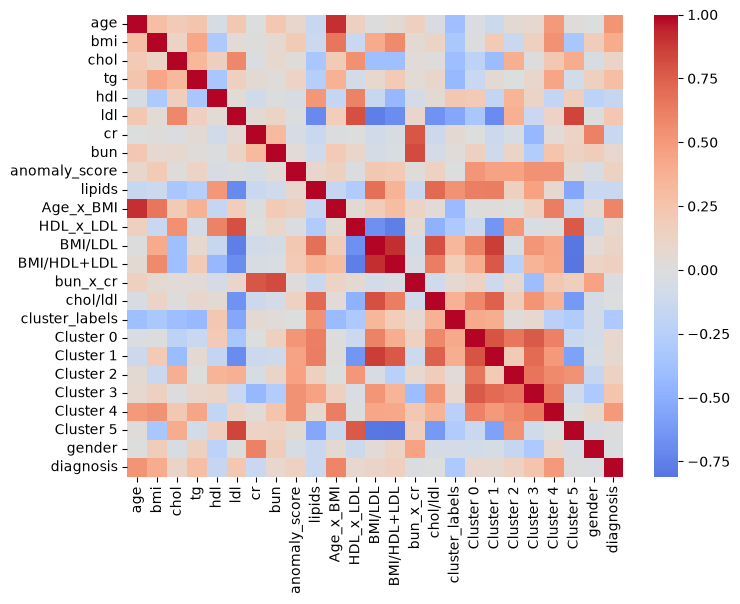

In [5]:


X_sub=pd.concat([X,df['diagnosis']],axis=1)
corr = X_sub.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=False,
            cmap="coolwarm",
            center=0)
plt.show()

In [6]:
df=pd.concat([X,y],axis=1)
pd.set_option('display.max_columns', None)
df = shuffle(df).reset_index(drop=True)
df.columns = df.columns.str.strip()
df.head(10)

# PATH="data/preprocessed/preprocessed.csv"
# saveFile(df,PATH)


,age,bmi,chol,tg,hdl,ldl,cr,bun,anomaly_score,lipids,Age_x_BMI,HDL_x_LDL,BMI/LDL,BMI/HDL+LDL,bun_x_cr,chol/ldl,cluster_labels,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,gender,diagnosis
0,62.0,30.0,3.60,2.34,0.90,2.500000,63.0,5.00,0,0.360000,1860.0,2.250000,12.000000,8.823529,315.000,1.440000,2,3.613922,5.636173,2.319321,4.184550,5.379752,7.363360,1,1.0
1,32.0,20.0,3.38,0.43,1.40,1.770000,57.1,4.00,0,0.790960,640.0,2.478000,11.299435,6.309148,228.400,1.909605,4,5.247358,6.286903,4.274371,5.003701,2.246628,7.720361,0,0.0
2,37.0,26.0,4.78,2.12,0.88,2.710000,96.4,5.11,0,0.324723,962.0,2.384800,9.594096,7.242340,492.604,1.763838,3,3.612248,4.987407,3.547476,2.345911,4.285910,8.261162,1,0.0
3,58.0,27.0,6.40,1.00,1.66,4.310000,62.0,6.25,0,0.385151,1566.0,7.154600,6.264501,4.522613,387.500,1.484919,1,4.305463,2.137258,6.194257,4.470370,5.377844,10.145332,0,0.0
4,48.0,25.0,6.28,1.85,1.37,4.110000,39.4,4.97,0,0.333333,1200.0,5.630700,6.082725,4.562044,195.818,1.527981,1,2.958092,2.745153,5.506990,4.802797,4.396065,9.698797,0,0.0
5,60.0,26.0,5.48,2.65,1.13,3.010000,73.6,4.51,0,0.375415,1560.0,3.401300,8.637874,6.280193,331.936,1.820598,0,1.360188,3.404530,3.061981,2.782272,4.140505,7.853804,1,0.0
6,43.0,24.0,5.83,1.91,1.31,4.450000,97.8,5.18,0,0.294382,1032.0,5.829500,5.393258,4.166667,506.604,1.310112,1,4.029224,2.597161,6.020510,3.350956,4.930949,10.594567,1,0.0
7,75.0,23.0,4.03,2.06,1.43,4.860753,60.9,3.92,0,0.294193,1725.0,6.950877,4.731777,3.656160,238.728,0.829090,1,4.390264,3.157217,6.389187,5.575911,5.778413,11.168479,0,1.0
8,35.0,30.0,4.55,0.86,1.45,2.630000,64.0,4.72,0,0.551331,1050.0,3.813500,11.406844,7.352941,302.080,1.730038,4,3.328583,4.418066,2.873780,3.360354,2.782790,7.253125,0,0.0
9,38.0,32.0,4.51,1.44,1.27,2.920000,101.6,5.80,1,0.434932,1216.0,3.708400,10.958904,7.637231,589.280,1.544521,3,5.293729,5.622263,4.854025,3.893115,5.817860,8.253795,1,0.0
